# Задание 1. Загрузка и профилирование данных

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install scikit-learn

Функция info:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  category      
 1   StockCode    541909 non-null  category      
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  Int64         
 7   Country      541909 non-null  category      
dtypes: Int64(1), category(3), datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 24.0 MB
None
Функция describe:
            Quantity                 InvoiceDate      UnitPrice   CustomerID
count  541909.000000                      541909  541909.000000     406829.0
mean        9.552250  2011-07-04 13:34:57.156386       4.611114  15287.69057
min    -80995.000000         201

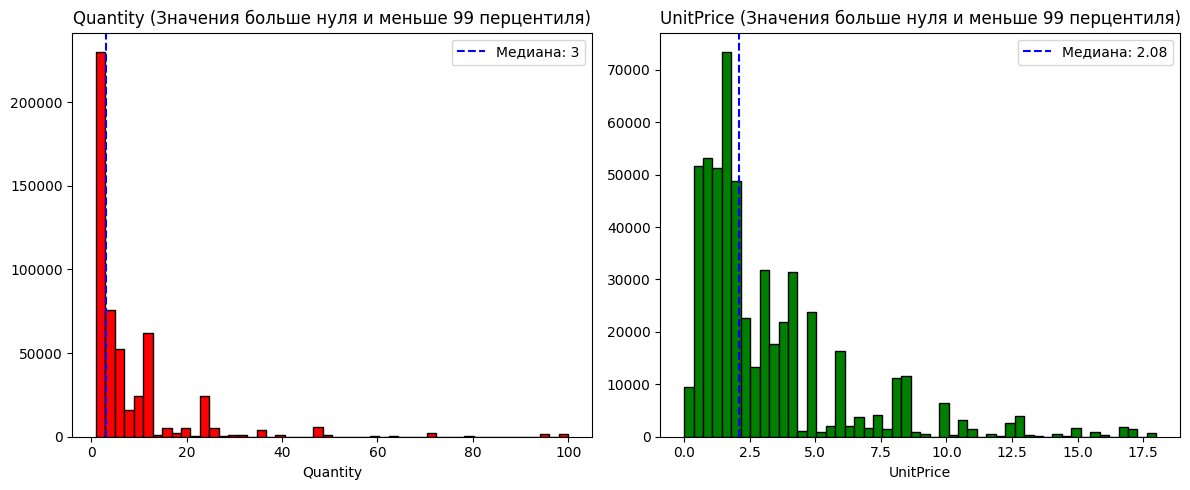

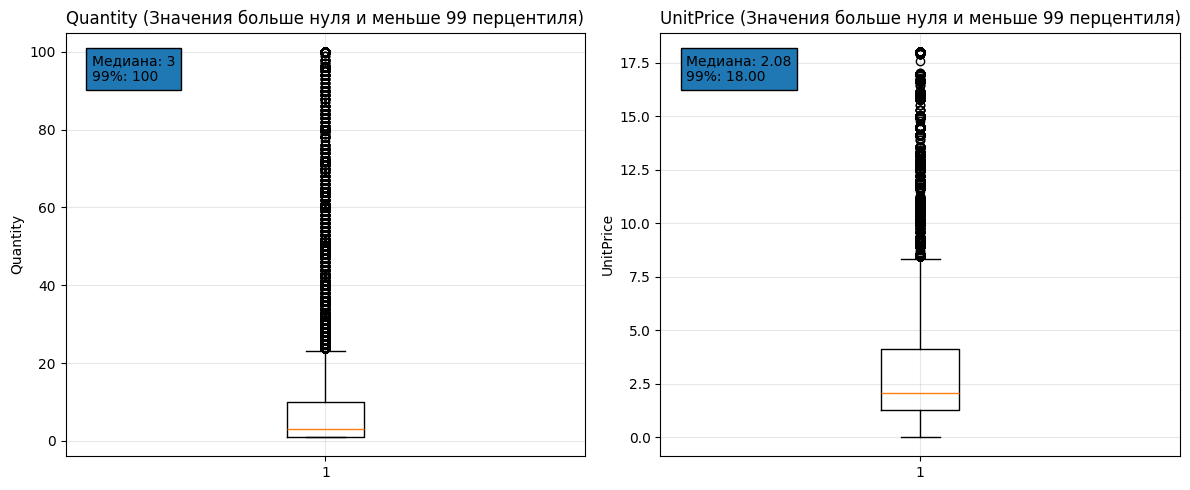

Вывод о наличии выбросов:
 В числовых признаках Quantity и UnitPrice содержится значительное количество выбросов, в том числе отрицательные и нулевые значения (10624 в Quantity и 2517 в UnitPrice).


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

df = pd.read_csv('../data/Online Retail.csv', sep=';')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df['UnitPrice'] = df['UnitPrice'].str.replace(',', '.').astype(float)
df['CustomerID'] = df['CustomerID'].astype('Int64')
df['InvoiceNo'] = df['InvoiceNo'].astype('category')
df['StockCode'] = df['StockCode'].astype('category')
df['Country'] = df['Country'].astype('category')

print("Функция info:")
print(df.info())
print("Функция describe:")
print(df.describe())

print("Наличие пропусков:")
missing_data = pd.DataFrame({
    'Количество пропусков': df.isnull().sum(),
    'Доля пропусков, %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_data)

print("Диапазоны значений:")
numeric_cols = ['Quantity', 'UnitPrice']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")

    print("Подозрительные экстремальные значения:")
    if col == 'Quantity':
        negative = (df[col] < 0).sum()
        print(f"  Отрицательные и нулевые значения: {negative}")
    
    if col == 'UnitPrice':
        zero_price = (df[col] == 0).sum()
        negative_price = (df[col] < 0).sum()
        print(f"  Нулевые цены: {zero_price}")
        print(f"  Отрицательные цены: {negative_price}")
print('\nInvoiceDate:')
min_date, max_date = np.min(df['InvoiceDate']), np.max(df['InvoiceDate'])
print(f"  Min: {min_date}, Max: {max_date}")
#-------------------

quantity_positive = df['Quantity'][df['Quantity'] > 0]
unitprice_positive = df['UnitPrice'][df['UnitPrice'] > 0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

q99_quantity = quantity_positive.quantile(0.99)
quantity_filtered = quantity_positive[quantity_positive <= q99_quantity]
axes[0].hist(quantity_filtered, bins=50, color="red", edgecolor='black')
axes[0].set_title(f"Quantity (Значения больше нуля и меньше 99 перцентиля)")
axes[0].set_xlabel("Quantity")
axes[0].axvline(quantity_positive.median(), color='blue', linestyle='--', label=f'Медиана: {quantity_positive.median():.0f}')
axes[0].legend()

q99_price = unitprice_positive.quantile(0.99)
unitprice_filtered = unitprice_positive[unitprice_positive <= q99_price]
axes[1].hist(unitprice_filtered, bins=50, color="green", edgecolor='black')
axes[1].set_title(f"UnitPrice (Значения больше нуля и меньше 99 перцентиля)")
axes[1].set_xlabel("UnitPrice")
axes[1].axvline(unitprice_positive.median(), color='blue', linestyle='--', label=f'Медиана: {unitprice_positive.median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

#-----------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
q99_quantity = quantity_positive.quantile(0.99)
quantity_box = quantity_positive[quantity_positive <= q99_quantity]
bp1 = axes[0].boxplot(quantity_box)
axes[0].set_title(f"Quantity (Значения больше нуля и меньше 99 перцентиля)")
axes[0].set_ylabel("Quantity")
axes[0].grid(True, alpha=0.3)

stats_text = f"Медиана: {quantity_positive.median():.0f}\n99%: {quantity_positive.quantile(0.99):.0f}"
axes[0].text(0.05, 0.95, stats_text, transform=axes[0].transAxes, 
             verticalalignment='top', bbox=dict())

# UnitPrice boxplot с фильтрацией и ограничением выбросов
q99_price = unitprice_positive.quantile(0.99)
price_box = unitprice_positive[unitprice_positive <= q99_price]
bp2 = axes[1].boxplot(price_box)
axes[1].set_title(f"UnitPrice (Значения больше нуля и меньше 99 перцентиля)")
axes[1].set_ylabel("UnitPrice")
axes[1].grid(True, alpha=0.3)

stats_text = f"Медиана: {unitprice_positive.median():.2f}\n99%: {unitprice_positive.quantile(0.99):.2f}"
axes[1].text(0.05, 0.95, stats_text, transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict())

plt.tight_layout()
plt.show()

print("Вывод о наличии выбросов:\n В числовых признаках Quantity и UnitPrice содержится значительное количество выбросов, в том числе отрицательные и нулевые значения (10624 в Quantity и 2517 в UnitPrice).")

# Задание 2. Проверка нормальности распределения

Вычислим описательные характеристики:

Quantity:
Среднее: 7.94
Медиана: 3.00
Стандартное отклонение: 12.58
Коэффициент асимметрии: 4.07
Коэффициент эксцесса: 21.63

UnitPrice:
Среднее: 3.13
Медиана: 2.08
Стандартное отклонение: 3.00
Коэффициент асимметрии: 2.07
Коэффициент эксцесса: 4.95
Выполним графический анализ:


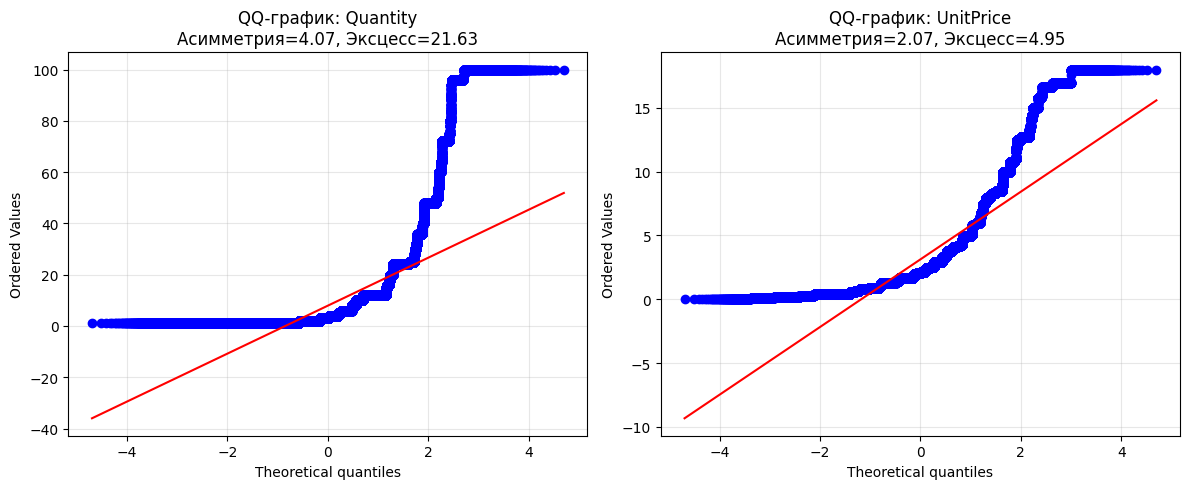

Сравнение с нормальным распределением:
Распределения значительно отличаются от нормального, коэффициенты ассиметрии и эксцесса принимают большие значения.
Отличие распределений от нормального объясняется спецификой данных а также отсутствием отрицательных значений количества и цены.
Распределение парампетра UnitPrice ближе к нормальному, но всё еще сильно отличается от него.

Проверим нормальность распределения признаков с помощью критерия Шапиро–Уилка
Quantity:

H0: выборка подчиняется нормальному распределению
H1: выборка не подчиняется нормальному распределению
Уровень значимости: α = 0.05
p-значение: 0.0000
H0 отвергается
Данные не соответствуют нормальному распределению. Значение статистики  0.5529861294093099
UnitPrice:

H0: выборка подчиняется нормальному распределению
H1: выборка не подчиняется нормальному распределению
Уровень значимости: α = 0.05
p-значение: 0.0000
H0 отвергается
Данные не соответствуют нормальному распределению. Значение статистики  0.7780316565255112


C:\Users\ilipa\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 526335.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\ilipa\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 534602.
  res = hypotest_fun_out(*samples, **kwds)


In [3]:
print("Вычислим описательные характеристики:")

print("\nQuantity:")
print(f"Среднее: {quantity_filtered.mean():.2f}")
print(f"Медиана: {quantity_filtered.median():.2f}")
print(f"Стандартное отклонение: {quantity_filtered.std():.2f}")
print(f"Коэффициент асимметрии: {quantity_filtered.skew():.2f}")
print(f"Коэффициент эксцесса: {quantity_filtered.kurtosis():.2f}")

print("\nUnitPrice:")
print(f"Среднее: {unitprice_filtered.mean():.2f}")
print(f"Медиана: {unitprice_filtered.median():.2f}")
print(f"Стандартное отклонение: {unitprice_filtered.std():.2f}")
print(f"Коэффициент асимметрии: {unitprice_filtered.skew():.2f}")
print(f"Коэффициент эксцесса: {unitprice_filtered.kurtosis():.2f}")

print("Выполним графический анализ:")

import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(quantity_filtered, dist="norm", plot=axes[0])
axes[0].set_title(f'QQ-график: Quantity\nАсимметрия={quantity_filtered.skew():.2f}, Эксцесс={quantity_filtered.kurtosis():.2f}')
axes[0].grid(True, alpha=0.3)

stats.probplot(unitprice_filtered, dist="norm", plot=axes[1])
axes[1].set_title(f'QQ-график: UnitPrice\nАсимметрия={unitprice_filtered.skew():.2f}, Эксцесс={unitprice_filtered.kurtosis():.2f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Сравнение с нормальным распределением:")

print("Распределения значительно отличаются от нормального, коэффициенты ассиметрии и эксцесса принимают большие значения.\nОтличие распределений от нормального объясняется спецификой данных а также отсутствием отрицательных значений количества и цены.\nРаспределение парампетра UnitPrice ближе к нормальному, но всё еще сильно отличается от него.")

# Не требуется в ТЗ: Сравнение с логнормальным распределением
#fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#stats.probplot(np.log(quantity_filtered), dist="norm", plot=axes[0])
#axes[0].set_title(f'QQ-график: log(Quantity))
#axes[0].grid(True, alpha=0.3)
#stats.probplot(np.log(unitprice_filtered), dist="norm", plot=axes[1])
#axes[1].set_title(f'QQ-график: log(UnitPrice))
#axes[1].grid(True, alpha=0.3)
#plt.tight_layout()
#plt.show()

print('\nПроверим нормальность распределения признаков с помощью критерия Шапиро–Уилка')

print('Quantity:')

print('\nH0: выборка подчиняется нормальному распределению')
print('H1: выборка не подчиняется нормальному распределению')
print('Уровень значимости: α = 0.05')

alpha = 0.05
stat, pvalue = stats.shapiro(quantity_filtered)

print(f"p-значение: {pvalue:.4f}")

if pvalue > alpha:
    print('Нет оснований отвергать H0')
    print('Данные могут соответствовать нормальному распределению. Значение статистики ', stat)
else:
    print('H0 отвергается')
    print('Данные не соответствуют нормальному распределению. Значение статистики ', stat)

print('UnitPrice:')

print('\nH0: выборка подчиняется нормальному распределению')
print('H1: выборка не подчиняется нормальному распределению')
print('Уровень значимости: α = 0.05')

alpha = 0.05
stat, pvalue = stats.shapiro(unitprice_filtered)

print(f"p-значение: {pvalue:.4f}")

if pvalue > alpha:
    print('Нет оснований отвергать H0')
    print('Данные могут соответствовать нормальному распределению. Значение статистики ', stat)
else:
    print('H0 отвергается')
    print('Данные не соответствуют нормальному распределению. Значение статистики ', stat)

# Задание 3. Обнаружение выбросов статистическими методами

Метод Z-score
Оба признака не соответствуют нормальному распределению, но UnitPrice ближе к нему. Далее будем работать этим признаком.
Всего наблюдений: 534602
Количество выбросов (|Z| > 3): 14719
Доля выбросов: 2.75%
Границы: Z = ±3 соответствует отклонению на ±3σ


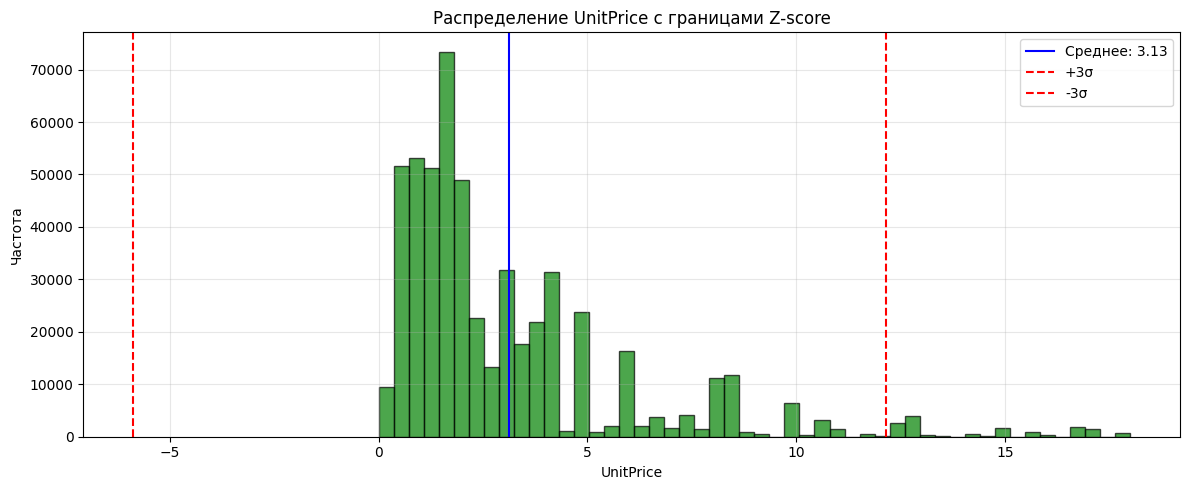

Метод IQR
Q1 (25-й процентиль): 1.25
Q3 (75-й процентиль): 4.13
IQR (межквартильный размах): 2.88
Нижняя граница: -3.07
Верхняя граница: 8.45
Количество выбросов (IQR): 34835
Доля выбросов: 6.52%

Сравнительный анализ методов

Метод           Количество выбросов  Доля выбросов  
--------------------------------------------------
Z-score (|Z|>3) 14719                2.75           %
IQR (1.5*IQR)   34835                6.52           %

Выбросы, обнаруженные обоими методами: 14719
Только Z-score: 0
Только IQR: 20116
Метод IQR обнаружил больше выбросов, чем Z-score


In [4]:
from scipy import stats
print('Метод Z-score')
print('Оба признака не соответствуют нормальному распределению, но UnitPrice ближе к нему. Далее будем работать этим признаком.')
z_scores = np.abs(stats.zscore(unitprice_filtered))

outliers = z_scores > 3
outliers_count = outliers.sum()
total_count = len(unitprice_filtered)

print(f"Всего наблюдений: {total_count}")
print(f"Количество выбросов (|Z| > 3): {outliers_count}")
print(f"Доля выбросов: {outliers_count/total_count*100:.2f}%")
print(f"Границы: Z = ±3 соответствует отклонению на ±3σ")

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

axes.hist(unitprice_filtered, bins=50, color='green', alpha=0.7, edgecolor='black')
axes.axvline(unitprice_filtered.mean(), color='blue', linestyle='-', label=f'Среднее: {unitprice_filtered.mean():.2f}')
axes.axvline(unitprice_filtered.mean() + 3*unitprice_filtered.std(), color='red', linestyle='--', label='+3σ')
axes.axvline(unitprice_filtered.mean() - 3*unitprice_filtered.std(), color='red', linestyle='--', label='-3σ')
axes.set_xlabel('UnitPrice')
axes.set_ylabel('Частота')
axes.set_title('Распределение UnitPrice с границами Z-score')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

outlier_values = unitprice_filtered[outliers]

print('Метод IQR')

Q1 = unitprice_filtered.quantile(0.25)
Q3 = unitprice_filtered.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = (unitprice_filtered < lower_bound) | (unitprice_filtered > upper_bound)
outliers_iqr_count = outliers_iqr.sum()

print(f"Q1 (25-й процентиль): {Q1:.2f}")
print(f"Q3 (75-й процентиль): {Q3:.2f}")
print(f"IQR (межквартильный размах): {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов (IQR): {outliers_iqr_count}")
print(f"Доля выбросов: {outliers_iqr_count/len(unitprice_filtered)*100:.2f}%")

print("\nСравнительный анализ методов\n")

outliers_zscore = z_scores > 3
outliers_zscore_count = outliers_zscore.sum()

print(f"{'Метод':<15} {'Количество выбросов':<20} {'Доля выбросов':<15}")
print("-"*50)
print(f"{'Z-score (|Z|>3)':<15} {outliers_zscore_count:<20} {outliers_zscore_count/len(unitprice_filtered)*100:<15.2f}%")
print(f"{'IQR (1.5*IQR)':<15} {outliers_iqr_count:<20} {outliers_iqr_count/len(unitprice_filtered)*100:<15.2f}%")

common_outliers = outliers_zscore & outliers_iqr
common_count = common_outliers.sum()
print(f"\nВыбросы, обнаруженные обоими методами: {common_count}")
print(f"Только Z-score: {(outliers_zscore & ~outliers_iqr).sum()}")
print(f"Только IQR: {(~outliers_zscore & outliers_iqr).sum()}")

if outliers_zscore_count > outliers_iqr_count:
    print("Метод Z-score обнаружил больше выбросов, чем IQR")
elif outliers_zscore_count < outliers_iqr_count:
    print("Метод IQR обнаружил больше выбросов, чем Z-score")
else:
    print("Оба метода обнаружили одинаковое количество выбросов")

# Задание 4. Метод локальной плотности

Текущая метрика: manhattan
Текущий метод: kth
Проведем обработку данных а также удалим дубликаты для корректного нахождения соседних точек
Было строк: 530104
Стало уникальных: 4402


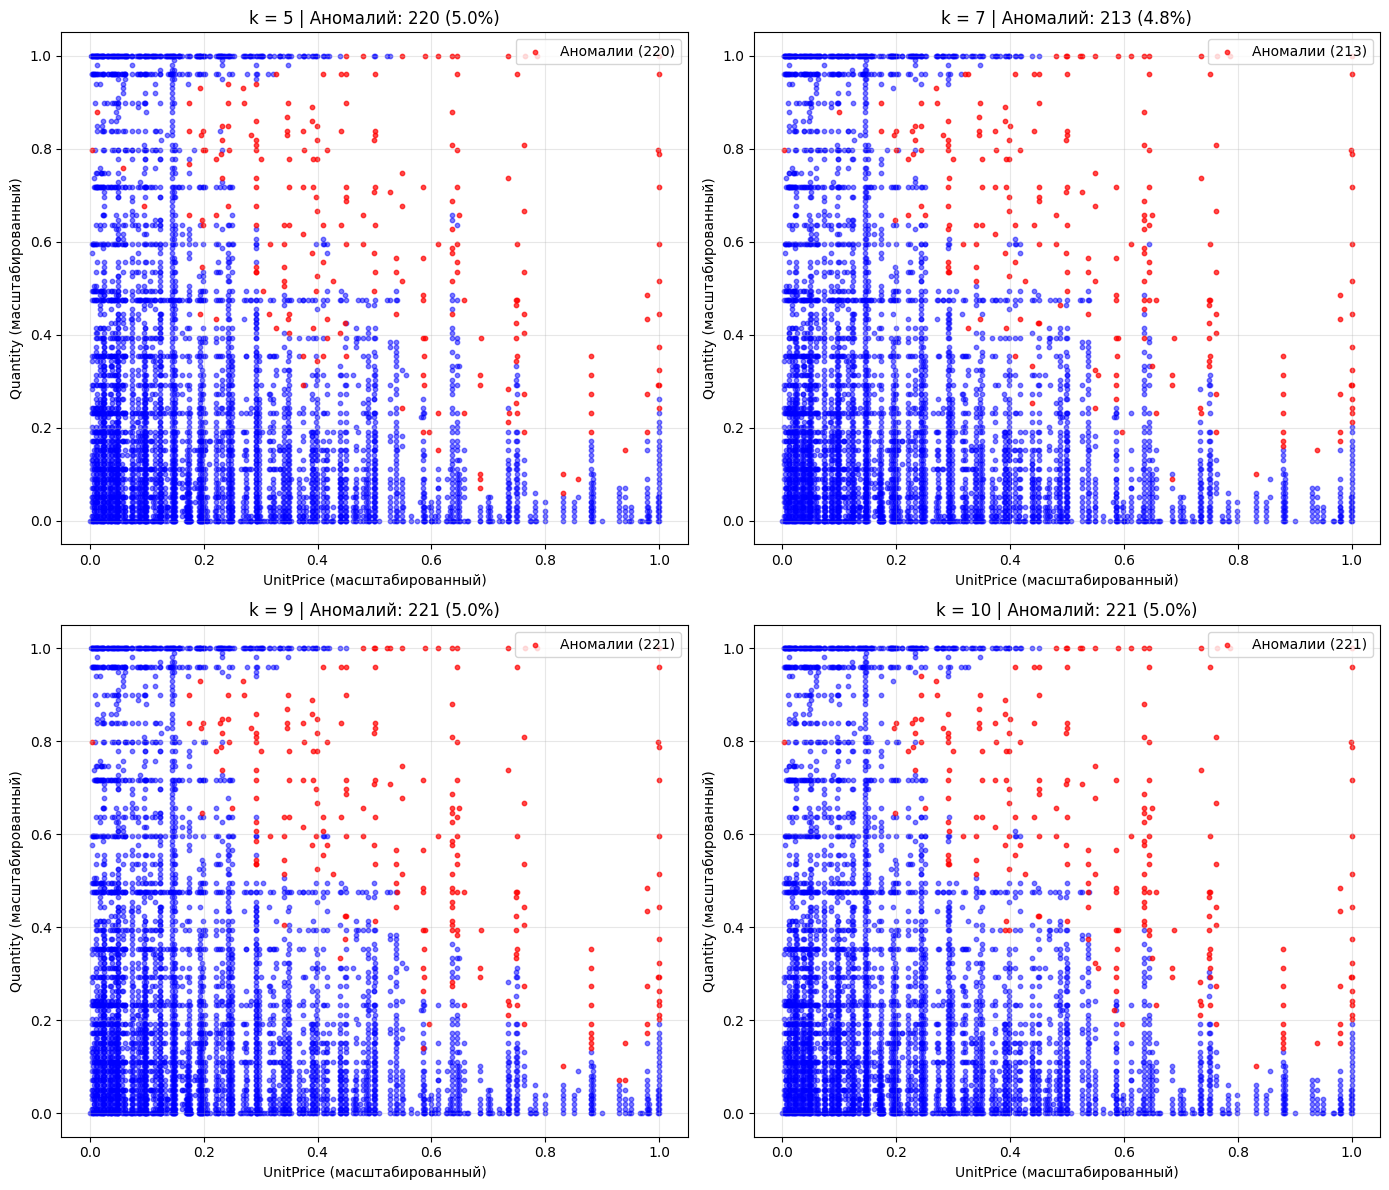

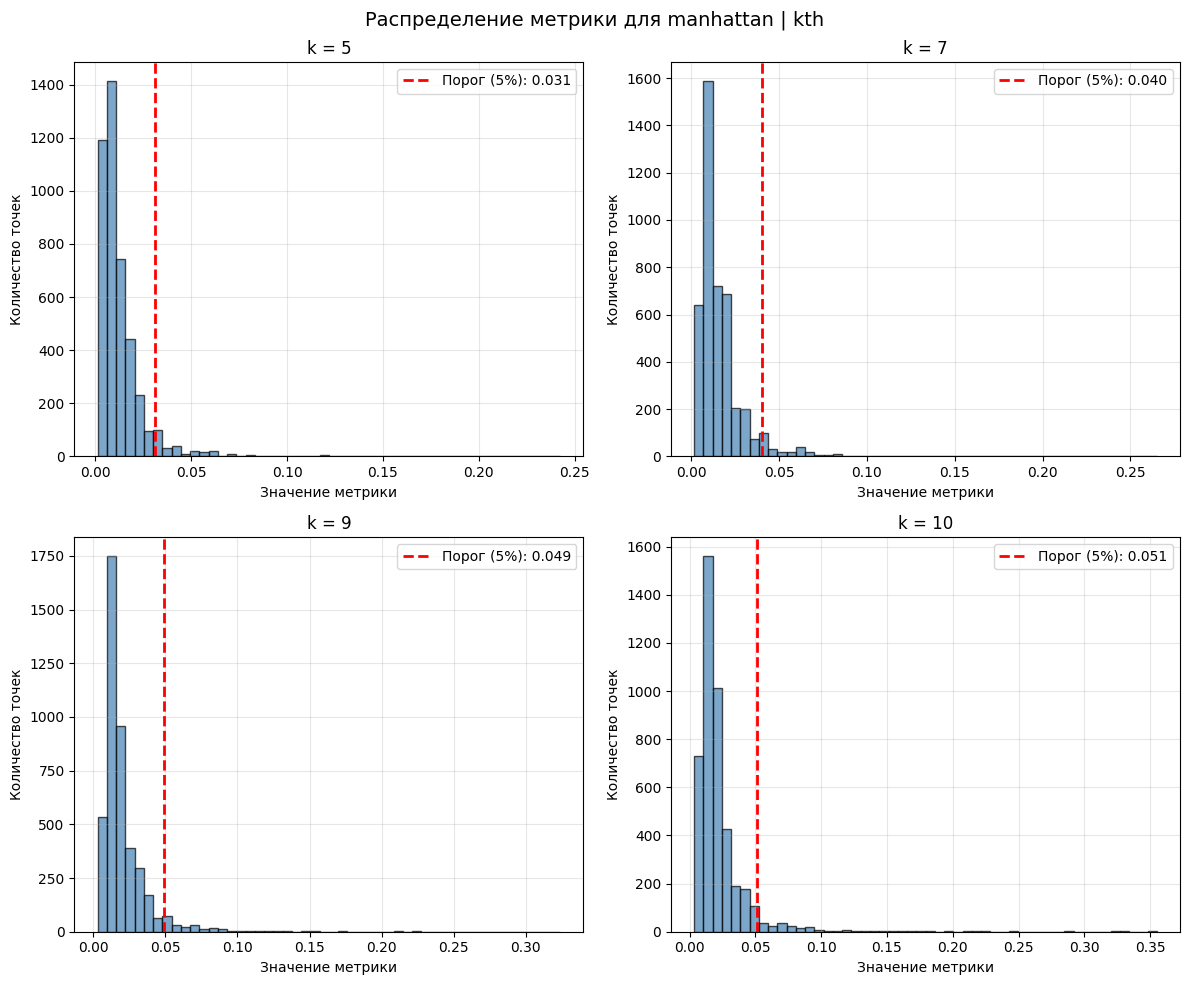

Анализ устойчивости метода
k=5: 220 аномалий (5.00%)
k=7: 213 аномалий (4.84%)
k=9: 221 аномалий (5.02%)
k=10: 221 аномалий (5.02%)
Размах: 8


In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

df_clean = df[['UnitPrice', 'Quantity']].copy()
df_clean = df_clean[(df_clean['UnitPrice'] > 0) & (df_clean['Quantity'] > 0)]

# Для изменения метрики раскомментировать необходимый вариант
# current_metric = 'euclidean'
current_metric = 'manhattan'

# Для изменения метода расхомментировать необходимый вариант
current_method = 'kth' # расстояние до k-го соседа
# current_method = 'mean' #среднее расстояние до k соседей
# current_method = 'density' #обратное среднее расстояние

print(f"Текущая метрика: {current_metric}")
print(f"Текущий метод: {current_method}")
print('Проведем обработку данных а также удалим дубликаты для корректного нахождения соседних точек')

upper_bound_price = df_clean['UnitPrice'].quantile(0.99)
upper_bound_quantity = df_clean['Quantity'].quantile(0.99)
df_clean['UnitPrice'] = np.where(df_clean['UnitPrice'] > upper_bound_price, upper_bound_price, df_clean['UnitPrice'])
df_clean['Quantity'] = np.where(df_clean['Quantity'] > upper_bound_quantity, upper_bound_quantity, df_clean['Quantity'])

df_unique = df_clean.drop_duplicates().copy()
print(f"Было строк: {len(df_clean)}")
print(f"Стало уникальных: {len(df_unique)}")

unitprice_filtered = df_unique['UnitPrice']
quantity_filtered = df_unique['Quantity']

X = np.column_stack((unitprice_filtered, quantity_filtered))

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

k_values = [5, 7, 9, 10]
alpha = 0.05
max_k = max(k_values)

neigh = NearestNeighbors(n_neighbors=max_k, algorithm='auto', n_jobs=-1, metric=current_metric)
neigh.fit(X_scaled)

distances, indices = neigh.kneighbors(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

anomalies_counts = []

for idx, k in enumerate(k_values):
    if current_method == 'kth':
        scores = distances[:, k-1]
        threshold = np.percentile(scores, (1 - alpha) * 100)
        anomalies = scores > threshold
    elif current_method == 'mean':
        scores = distances[:, :k].mean(axis=1)
        threshold = np.percentile(scores, (1 - alpha) * 100)
        anomalies = scores > threshold
    elif current_method == 'density':
        mean_dist = distances[:, :k].mean(axis=1)
        scores = 1.0 / (mean_dist + 1e-10)
        threshold = np.percentile(scores, alpha * 100)
        anomalies = scores < threshold

    anomalies_counts.append(anomalies.sum())
    ax = axes[idx]
    ax.scatter(
        X_scaled[~anomalies, 0], X_scaled[~anomalies, 1],
        c='blue', s=10, alpha=0.5
    )
    ax.scatter(
        X_scaled[anomalies, 0], X_scaled[anomalies, 1],
        c='red', s=10, alpha=0.7, label=f'Аномалии ({anomalies.sum()})'
    )
    ax.set_title(f'k = {k} | Аномалий: {anomalies.sum()} ({anomalies.sum()/len(X_scaled)*100:.1f}%)')
    ax.set_xlabel('UnitPrice (масштабированный)')
    ax.set_ylabel('Quantity (масштабированный)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    if current_method == 'kth':
        scores = distances[:, k-1]
        threshold = np.percentile(scores, 95)
    elif current_method == 'mean':
        scores = distances[:, :k].mean(axis=1)
        threshold = np.percentile(scores, 95)
    elif current_method == 'density':
        mean_dist = distances[:, :k].mean(axis=1)
        scores = 1.0 / (mean_dist + 1e-10)
        threshold = np.percentile(scores, 5)  # плотность: аномалии — это нижние 5%
    
    ax = axes[idx]
    ax.hist(scores, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(threshold, color='red', linewidth=2, linestyle='--', label=f'Порог (5%): {threshold:.3f}')
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Значение метрики')
    ax.set_ylabel('Количество точек')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Распределение метрики для {current_metric} | {current_method}', fontsize=14)
plt.tight_layout()
plt.show()

print("Анализ устойчивости метода")
for k, cnt in zip(k_values, anomalies_counts):
    print(f"k={k}: {cnt} аномалий ({cnt/len(X_scaled)*100:.2f}%)")

print(f"Размах: {max(anomalies_counts) - min(anomalies_counts)}")

In [6]:
def find_anomalies(X_scaled, metric, method, k, alpha=0.05):
    neigh = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    neigh.fit(X_scaled)
    distances, indices = neigh.kneighbors(X_scaled)
    
    if method == 'kth':
        scores = distances[:, -1]
        threshold = np.percentile(scores, (1 - alpha) * 100)
        anomalies = scores > threshold
    elif method == 'mean':
        scores = distances.mean(axis=1)
        threshold = np.percentile(scores, (1 - alpha) * 100)
        anomalies = scores > threshold
    elif method == 'density':
        scores = 1.0 / (distances.mean(axis=1) + 1e-10)
        threshold = np.percentile(scores, alpha * 100)
        anomalies = scores < threshold    
    return anomalies, scores, threshold

results = []

k_values = [5, 7, 9, 10]
metrics = ['euclidean', 'manhattan']
methods = ['kth', 'mean', 'density']

for metric in metrics:
    for method in methods:
        for k in k_values:
            anomalies, scores, thresh = find_anomalies(X_scaled, metric, method, k, alpha=0.05)
            results.append({
                'metric': metric,
                'method': method,
                'k': k,
                'anomaly_count': anomalies.sum(),
                'threshold': thresh
            })

df_results = pd.DataFrame(results)
pivot = df_results.pivot_table(index=['method', 'metric'], columns='k', values='anomaly_count')
print(pivot)

k                     5      7      9      10
method  metric                               
density euclidean  221.0  221.0  221.0  221.0
        manhattan  221.0  221.0  221.0  221.0
kth     euclidean  219.0  221.0  221.0  221.0
        manhattan  220.0  213.0  221.0  221.0
mean    euclidean  221.0  221.0  221.0  221.0
        manhattan  221.0  221.0  221.0  221.0
